# Model Development

مقارنة مختصرة وواضحة بين نماذج شجرية مناسبة للمشروع:
- `decision_tree_balanced` على البيانات الأصلية مع `class_weight='balanced'`
- `decision_tree_smote` على بيانات تدريب متوازنة باستخدام `SMOTE`
- `random_forest_balanced` على البيانات الأصلية مع `class_weight='balanced'`
- `random_forest_smote` على بيانات تدريب متوازنة باستخدام `SMOTE`

التركيز هنا على وضوح المقارنة بين `Decision Tree` و`Random Forest` مع الاهتمام بمقاييس الفئة الإيجابية مثل `Recall` و `F1-score`.

In [2]:
import json
import pickle
from pathlib import Path

import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt


### 📦 الخلية 2: استيراد المكتبات الأساسية
استيراد جميع المكتبات المطلوبة للعمل مع البيانات والنماذج والرسوم

In [3]:
BASE_DIR = Path.cwd().parent
RAW_DATA_PATH = BASE_DIR / "data" / "student_lifestyle_100k.csv"

with open("../data/preprocessed_original.pkl", "rb") as f:
    X_train_original, X_val_scaled, X_test_scaled, y_train_original, y_val, y_test = pickle.load(f)

with open("preprocessed_smote.pkl", "rb") as f:
    X_train_smote, _, _, y_train_smote, _, _ = pickle.load(f)        
feature_names = (
    pd.read_csv(RAW_DATA_PATH, nrows=1)
    .drop(columns=["Student_ID", "Depression"])
    .columns
    .tolist()
)

feature_names


['Age',
 'Gender',
 'Department',
 'CGPA',
 'Sleep_Duration',
 'Study_Hours',
 'Social_Media_Hours',
 'Physical_Activity',
 'Stress_Level']

### 📂 الخلية 3: تحميل البيانات والميزات
تحميل:
- البيانات المعالجة الأصلية (Train/Val/Test)
- البيانات المعالجة بـ SMOTE
- قائمة أسماء الميزات من البيانات الخام

In [4]:
train_distribution_df = pd.concat(
    {
        "original_count": pd.Series(y_train_original).value_counts().sort_index(),
        "original_ratio": pd.Series(y_train_original).value_counts(normalize=True).sort_index(),
        "smote_count": pd.Series(y_train_smote).value_counts().sort_index(),
        "smote_ratio": pd.Series(y_train_smote).value_counts(normalize=True).sort_index(),
    },
    axis=1,
)

train_distribution_df.index.name = "class"
train_distribution_df.round(4)


,original_count,original_ratio,smote_count,smote_ratio
class,,,,
0,71950,0.8994,71950,0.5
1,8050,0.1006,71950,0.5


### ⚖️ الخلية 4: مقارنة توزيع الفئات
جدول مقارن يعرض:
- العدد والنسبة للبيانات الأصلية
- العدد والنسبة بعد SMOTE
- يوضح كيف ساعد SMOTE في توازن البيانات

In [5]:
from sklearn.linear_model import LogisticRegression


def evaluate_predictions(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_class_0": report["0"]["precision"],
        "recall_class_0": report["0"]["recall"],
        "f1_class_0": report["0"]["f1-score"],
        "precision_class_1": report["1"]["precision"],
        "recall_class_1": report["1"]["recall"],
        "f1_class_1": report["1"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "report": report,
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    }


def run_experiment(name, model, X_train_used, y_train_used):
    model.fit(X_train_used, y_train_used)

    y_val_pred = model.predict(X_val_scaled)
    y_test_pred = model.predict(X_test_scaled)

    val_metrics = evaluate_predictions(y_val, y_val_pred)
    test_metrics = evaluate_predictions(y_test, y_test_pred)

    return {
        "experiment": name,
        "model_type": type(model).__name__,
        "train_samples": int(len(y_train_used)),
        "train_positive_ratio": float(pd.Series(y_train_used).mean()),
        "val_accuracy": val_metrics["accuracy"],
        "val_precision_class_1": val_metrics["precision_class_1"],
        "val_recall_class_1": val_metrics["recall_class_1"],
        "val_f1_class_1": val_metrics["f1_class_1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision_class_0": test_metrics["precision_class_0"],
        "test_recall_class_0": test_metrics["recall_class_0"],
        "test_f1_class_0": test_metrics["f1_class_0"],
        "test_precision_class_1": test_metrics["precision_class_1"],
        "test_recall_class_1": test_metrics["recall_class_1"],
        "test_f1_class_1": test_metrics["f1_class_1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
        "val_report": val_metrics["report"],
        "test_report": test_metrics["report"],
        "test_confusion_matrix": test_metrics["confusion_matrix"],
        "model": model,
    }


experiments = {
    "logistic_smote": (
        LogisticRegression(
            random_state=42,
            max_iter=1000
        ),
        X_train_smote,
        y_train_smote,
    ),
    "logistic_balanced": (
        LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        ),
        X_train_original,
        y_train_original,
   ),
    "decision_tree_balanced": (
        DecisionTreeClassifier(
            random_state=42,
            max_depth=8,
            min_samples_leaf=20,
            class_weight="balanced",
        ),
        X_train_original,
        y_train_original,
    ),
    "decision_tree_smote": (
        DecisionTreeClassifier(
            random_state=42,
            max_depth=8,
            min_samples_leaf=20,
        ),
        X_train_smote,
        y_train_smote,
    ),
    "random_forest_balanced": (
        RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
        ),
        X_train_original,
        y_train_original,
    ),
    "random_forest_smote": (
        RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            max_depth=12,
            min_samples_leaf=5,
            n_jobs=-1,
        ),
        X_train_smote,
        y_train_smote,
    ),
}

trained_models = {}
results = []

for name, (model, X_train_used, y_train_used) in experiments.items():
    result = run_experiment(name, model, X_train_used, y_train_used)
    trained_models[name] = result.pop("model")
    results.append(result)

results_df = (
    pd.DataFrame(results)
    .sort_values(by=["test_f1_class_1", "test_recall_class_1"], ascending=False)
    .reset_index(drop=True)
)

results_df[["experiment", "model_type", "test_accuracy", "test_recall_class_1", "test_f1_class_1"]].round(4)


,experiment,model_type,test_accuracy,test_recall_class_1,test_f1_class_1
0,random_forest_balanced,RandomForestClassifier,0.7404,0.5845,0.3118
1,decision_tree_balanced,DecisionTreeClassifier,0.7293,0.6064,0.3107
2,decision_tree_smote,DecisionTreeClassifier,0.7486,0.5388,0.3013
3,random_forest_smote,RandomForestClassifier,0.7576,0.5040,0.2949
4,logistic_smote,LogisticRegression,0.6166,0.6431,0.2523
5,logistic_balanced,LogisticRegression,0.6155,0.6441,0.2521


### 🧪 الخلية 5: تعريف الدوال وتشغيل التجارب
**الدوال:**
- `evaluate_predictions()`: حساب مقاييس الأداء (Accuracy, Precision, Recall, F1)
- `run_experiment()`: تدريب واختبار نموذج واحد

**التجارب (6 نماذج):**
| النموذج | البيانات | الطريقة |
|---------|---------|--------|
| Logistic Regression | SMOTE | غير متوازن |
| Logistic Regression | أصلية | Balanced |
| Decision Tree | أصلية | Balanced |
| Decision Tree | SMOTE | غير متوازن |
| Random Forest | أصلية | Balanced |
| Random Forest | SMOTE | غير متوازن |

**النتيجة:** جدول مرتب حسب F1-score

## Summary Comparison

هذا الجدول هو المرجع السريع لاتخاذ القرار، مع التركيز على `test_f1_class_1` و `test_recall_class_1`.

In [6]:
summary_columns = [
    "experiment",
    "model_type",
    "train_positive_ratio",
    "test_accuracy",
    "test_precision_class_1",
    "test_recall_class_1",
    "test_f1_class_1",
    "test_macro_f1",
    "test_weighted_f1",
]

summary_df = (
    results_df[summary_columns]
    .sort_values(by=["test_f1_class_1", "test_recall_class_1"], ascending=False)
    .reset_index(drop=True)
    .round(4)
)

summary_df


,experiment,model_type,train_positive_ratio,test_accuracy,test_precision_class_1,test_recall_class_1,test_f1_class_1,test_macro_f1,test_weighted_f1
0,random_forest_balanced,RandomForestClassifier,0.1006,0.7404,0.2126,0.5845,0.3118,0.5759,0.7869
1,decision_tree_balanced,DecisionTreeClassifier,0.1006,0.7293,0.2088,0.6064,0.3107,0.5711,0.7792
2,decision_tree_smote,DecisionTreeClassifier,0.5000,0.7486,0.2091,0.5388,0.3013,0.5740,0.7919
3,random_forest_smote,RandomForestClassifier,0.5000,0.7576,0.2085,0.5040,0.2949,0.5743,0.7974
4,logistic_smote,LogisticRegression,0.5000,0.6166,0.1570,0.6431,0.2523,0.4973,0.6929
5,logistic_balanced,LogisticRegression,0.1006,0.6155,0.1567,0.6441,0.2521,0.4967,0.6920


### 📊 الخلية 7: جدول الملخص السريع
عرض أهم المقاييس:
- معلومات النموذج والتدريب
- Accuracy على بيانات الاختبار
- Precision, Recall, F1 للفئة الموجبة
- Macro و Weighted F1

مرتب حسب الأداء الأفضل

## Detailed Comparison

هذا الجدول يبقي التفاصيل المهمة كلها في مكان واحد بدل تكرار تقارير طويلة لكل تجربة.

In [7]:
detailed_columns = [
    "experiment",
    "model_type",
    "train_samples",
    "train_positive_ratio",
    "val_accuracy",
    "val_precision_class_1",
    "val_recall_class_1",
    "val_f1_class_1",
    "test_accuracy",
    "test_precision_class_0",
    "test_recall_class_0",
    "test_f1_class_0",
    "test_precision_class_1",
    "test_recall_class_1",
    "test_f1_class_1",
    "test_macro_f1",
    "test_weighted_f1",
    "tn",
    "fp",
    "fn",
    "tp",
]

detailed_df = (
    results_df[detailed_columns]
    .sort_values(by=["test_f1_class_1", "test_recall_class_1"], ascending=False)
    .reset_index(drop=True)
    .round(4)
)

detailed_df


,experiment,model_type,train_samples,train_positive_ratio,val_accuracy,val_precision_class_1,val_recall_class_1,val_f1_class_1,test_accuracy,test_precision_class_0,...,test_f1_class_0,test_precision_class_1,test_recall_class_1,test_f1_class_1,test_macro_f1,test_weighted_f1,tn,fp,fn,tp
0,random_forest_balanced,RandomForestClassifier,80000,0.1006,0.7432,0.2217,0.6183,0.3263,0.7404,0.9422,...,0.8400,0.2126,0.5845,0.3118,0.5759,0.7869,6816,2178,418,588
1,decision_tree_balanced,DecisionTreeClassifier,80000,0.1006,0.7341,0.2207,0.6491,0.3294,0.7293,0.9441,...,0.8316,0.2088,0.6064,0.3107,0.5711,0.7792,6683,2311,396,610
2,decision_tree_smote,DecisionTreeClassifier,143900,0.5000,0.7530,0.2215,0.5785,0.3203,0.7486,0.9374,...,0.8467,0.2091,0.5388,0.3013,0.5740,0.7919,6944,2050,464,542
3,random_forest_smote,RandomForestClassifier,143900,0.5000,0.7625,0.2243,0.5537,0.3193,0.7576,0.9341,...,0.8536,0.2085,0.5040,0.2949,0.5743,0.7974,7069,1925,499,507
4,logistic_smote,LogisticRegression,143900,0.5000,0.6215,0.1669,0.6918,0.2689,0.6166,0.9389,...,0.7422,0.1570,0.6431,0.2523,0.4973,0.6929,5519,3475,359,647
5,logistic_balanced,LogisticRegression,80000,0.1006,0.6210,0.1667,0.6918,0.2686,0.6155,0.9390,...,0.7412,0.1567,0.6441,0.2521,0.4967,0.6920,5507,3487,358,648


### 🔍 الخلية 9: جدول التفاصيل الكاملة
جدول شامل يتضمن:
- معلومات التدريب والتحقق
- جميع مقاييس الاختبار (Precision, Recall, F1 لكل فئة)
- عناصر مصفوفة الالتباس (TP, TN, FP, FN)
- جميع النماذج مقارنة في جدول واحد

## Focused Best-Model Report

بدل عرض تقرير كامل لكل تجربة، نعرض هنا التقرير التفصيلي للنموذج الأفضل حسب `test_f1_class_1`.

In [8]:
focus_model_name = summary_df.iloc[0]["experiment"]
focus_row = results_df.loc[results_df["experiment"] == focus_model_name].iloc[0]

focus_test_report_df = (
    pd.DataFrame(focus_row["test_report"])
    .T
    .loc[["0", "1", "accuracy", "macro avg", "weighted avg"]]
    .round(4)
)

focus_confusion_df = pd.DataFrame(
    focus_row["test_confusion_matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

display(pd.DataFrame([focus_row[["experiment", "model_type", "test_accuracy", "test_recall_class_1", "test_f1_class_1"]]]).round(4))
display(focus_test_report_df)
focus_confusion_df


,experiment,model_type,test_accuracy,test_recall_class_1,test_f1_class_1
0,random_forest_balanced,RandomForestClassifier,0.7404,0.5845,0.3118


,precision,recall,f1-score,support
0,0.9422,0.7578,0.8400,8994.0000
1,0.2126,0.5845,0.3118,1006.0000
accuracy,0.7404,0.7404,0.7404,0.7404
macro avg,0.5774,0.6712,0.5759,10000.0000
weighted avg,0.8688,0.7404,0.7869,10000.0000


,Predicted 0,Predicted 1
Actual 0,6816,2178
Actual 1,418,588


### 🏆 الخلية 11: تقرير النموذج الأفضل المفصل
عرض معلومات شاملة للنموذج الأفضل فقط:
- اسم التجربة ونوع النموذج ومقاييس الأداء الرئيسية
- تقرير التصنيف التفصيلي (Precision, Recall, F1 لكل فئة)
- مصفوفة الالتباس (كم صح/خطأ في التنبؤات)

## Feature Importance

هذه الخلية تساعد في تفسير النتائج، وهي نقطة مهمة في التقرير والعرض النهائي.

In [9]:
best_model_name = summary_df.iloc[0]["experiment"]
best_model = trained_models[best_model_name]

feature_importance_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": best_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df


,feature,importance
0,CGPA,0.527856
1,Stress_Level,0.103684
2,Sleep_Duration,0.097960
3,Physical_Activity,0.072078
4,Study_Hours,0.069917
5,Social_Media_Hours,0.066195
6,Age,0.029176
7,Department,0.023915
8,Gender,0.009219


### ⭐ الخلية 13: أهمية الميزات
استخراج قيم أهمية كل ميزة من النموذج الأفضل:
- جدول يحتوي على اسم الميزة ودرجة الأهمية (0-1)
- مرتب تنازليًا (الميزات الأهم أولاً)
- يساعد في فهم أي العوامل لها التأثير الأكبر على التنبؤ

## Saved Models

يتم حفظ النموذج الأفضل إجمالًا، مع حفظ أفضل `Decision Tree` وأفضل `Random Forest` بشكل منفصل، بالإضافة إلى ملفات CSV وJSON المساعدة.

In [10]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

summary_df.to_csv(results_dir / "tree_model_comparison.csv", index=False)
feature_importance_df.to_csv(results_dir / "best_tree_feature_importance.csv", index=False)

decision_tree_best_name = (
    results_df[results_df["model_type"] == "DecisionTreeClassifier"].iloc[0]["experiment"]
)
random_forest_best_name = (
    results_df[results_df["model_type"] == "RandomForestClassifier"].iloc[0]["experiment"]
)

with open("../models/saved_tree_best_model.pkl", "wb") as f:
    pickle.dump(trained_models[best_model_name], f)

with open("../models/saved_decision_tree.pkl", "wb") as f:
    pickle.dump(trained_models[decision_tree_best_name], f)

with open("../models/saved_random_forest.pkl", "wb") as f:
    pickle.dump(trained_models[random_forest_best_name], f)

summary_df.to_csv("../results/tree_model_comparison.csv", index=False)
feature_importance_df.to_csv("../results/best_tree_feature_importance.csv", index=False)

details_payload = {
    "best_experiment": best_model_name,
    "decision_tree_best_experiment": decision_tree_best_name,
    "random_forest_best_experiment": random_forest_best_name,
    "results": results,
}

with open("../results/tree_model_details.json", "w", encoding="utf-8") as f:
    json.dump(details_payload, f, ensure_ascii=False, indent=2)

{
    "best_experiment": best_model_name,
    "decision_tree_best_experiment": decision_tree_best_name,
    "random_forest_best_experiment": random_forest_best_name,
    "saved_files": [
        "../models/saved_tree_best_model.pkl",
        "../models/saved_decision_tree.pkl",
        "../models/saved_random_forest.pkl",
        "tree_model_comparison.csv",
        "best_tree_feature_importance.csv",
        "tree_model_details.json",
    ],
}


{'best_experiment': 'random_forest_balanced',
 'decision_tree_best_experiment': 'decision_tree_balanced',
 'random_forest_best_experiment': 'random_forest_balanced',
 'saved_files': ['../models/saved_tree_best_model.pkl',
  '../models/saved_decision_tree.pkl',
  '../models/saved_random_forest.pkl',
  'tree_model_comparison.csv',
  'best_tree_feature_importance.csv',
  'tree_model_details.json']}

### 💾 الخلية 15: حفظ النماذج والملفات
حفظ المخرجات:
- **النماذج** (3 ملفات pickle):
  - أفضل نموذج عام
  - أفضل Decision Tree
  - أفضل Random Forest

- **النتائج** (3 ملفات):
  - `tree_model_comparison.csv`: جدول الملخص
  - `best_tree_feature_importance.csv`: أهمية الميزات
  - `tree_model_details.json`: بيانات كاملة

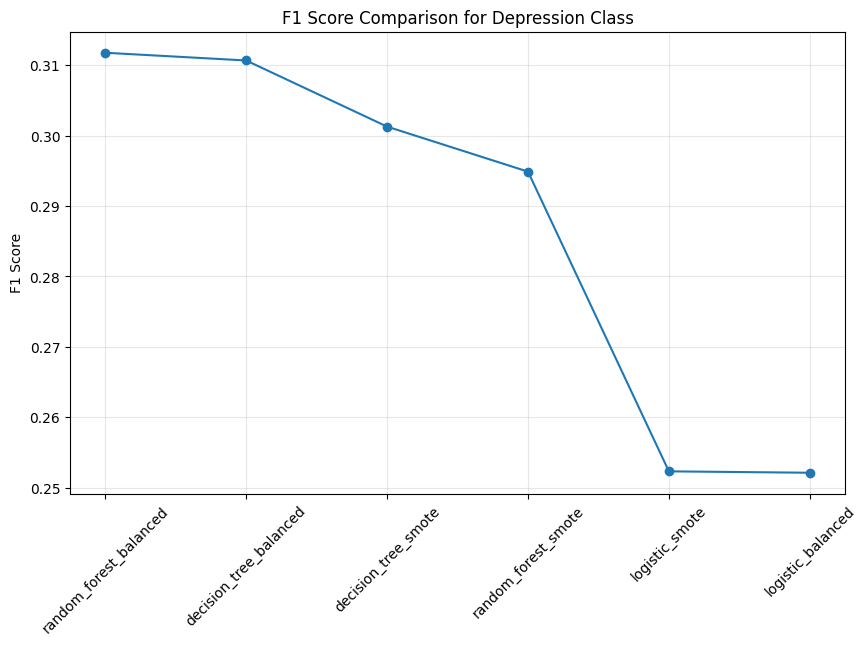

In [11]:
plt.figure(figsize=(10,6))

plt.plot(
    summary_df["experiment"],
    summary_df["test_f1_class_1"],
    marker='o'
)

plt.title("F1 Score Comparison for Depression Class")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

### 📈 الخلايا 16-18: رسوم بيانية مقارنة
- **الخلية 16**: رسم F1-score لجميع النماذج
- **الخلية 17**: رسم Recall لجميع النماذج (مهم جداً لكشف الاكتئاب)
- **الخلية 18**: مقارنة ثلاث مقاييس معاً (Precision, Recall, F1)

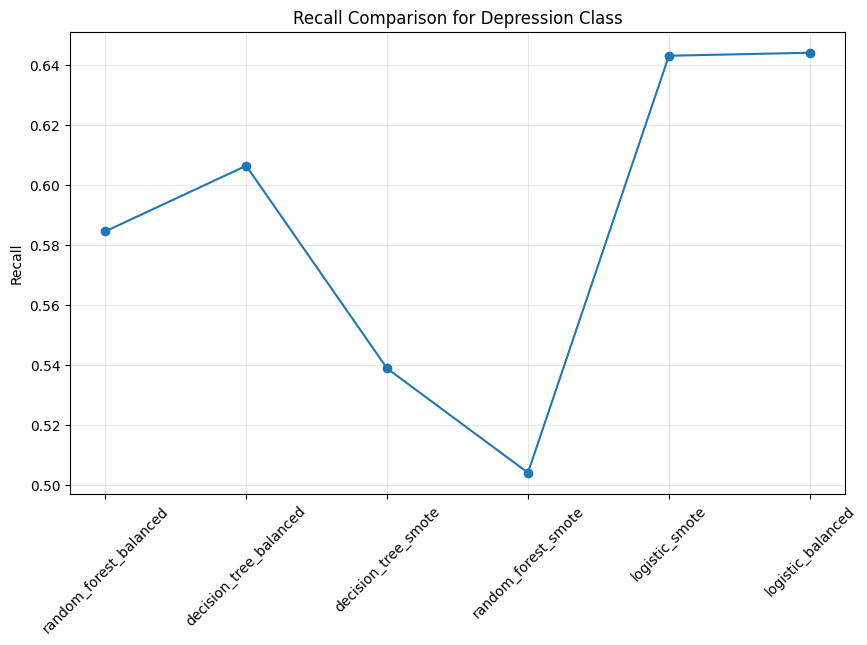

In [12]:
plt.figure(figsize=(10,6))

plt.plot(
    summary_df["experiment"],
    summary_df["test_recall_class_1"],
    marker='o'
)

plt.title("Recall Comparison for Depression Class")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

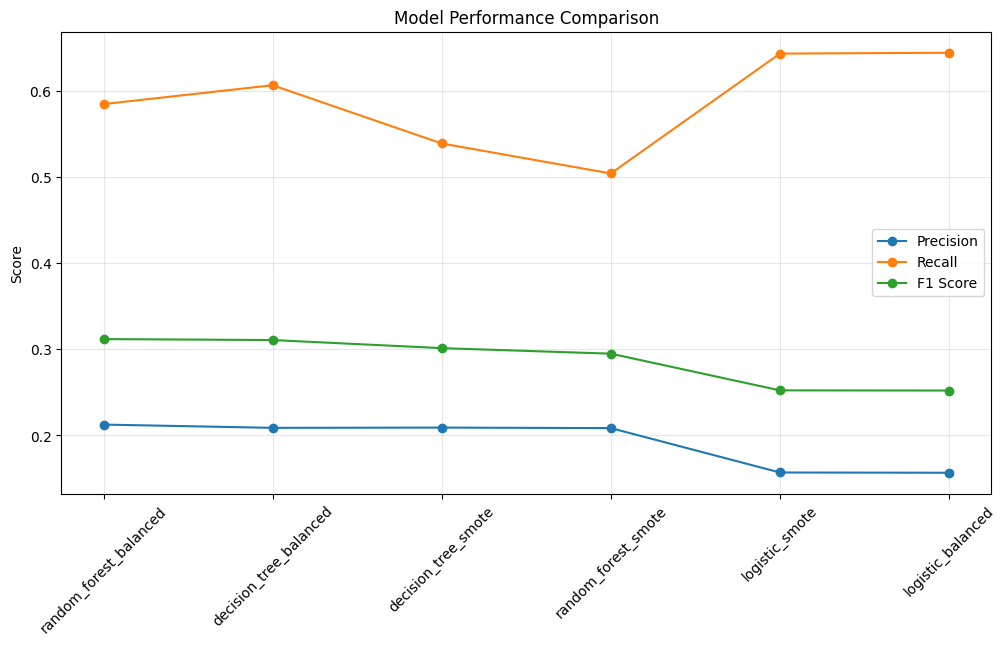

In [13]:
plt.figure(figsize=(12,6))

plt.plot(summary_df["experiment"], summary_df["test_precision_class_1"], marker='o', label='Precision')
plt.plot(summary_df["experiment"], summary_df["test_recall_class_1"], marker='o', label='Recall')
plt.plot(summary_df["experiment"], summary_df["test_f1_class_1"], marker='o', label='F1 Score')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Overfitting Detection

مقارنة أداء النموذج على بيانات التدريب والتحقق والاختبار لكشف الـ Overfitting


In [16]:
# حساب أداء أفضل نموذج على التدريب والتحقق والاختبار
best_model_name = summary_df.iloc[0]["experiment"]
best_model = trained_models[best_model_name]

# التنبؤات على جميع المجموعات
y_train_pred = best_model.predict(X_train_original)
y_val_pred = best_model.predict(X_val_scaled)
y_test_pred = best_model.predict(X_test_scaled)

# حساب Accuracy
train_acc = accuracy_score(y_train_original, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# حساب الفروقات
train_val_gap = train_acc - val_acc
train_test_gap = train_acc - test_acc

overfitting_df = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Accuracy": [train_acc, val_acc, test_acc],
    "Gap from Train": [0, train_val_gap, train_test_gap]
}).round(4)

display(overfitting_df)

# تحليل الـ Overfitting
print("\n📊 تحليل الـ Overfitting:")
print(f"النموذج الأفضل: {best_model_name}\n")

if train_test_gap < 0.05:
    print("✅ لا يوجد overfitting واضح - النموذج متوازن")
elif train_test_gap < 0.10:
    print("⚠️  overfitting طفيف - النموذج يعمل بشكل معقول")
else:
    print("⛔ overfitting واضح - النموذج متفرط على بيانات التدريب")

print(f"\nالفرق بين Train و Test: {train_test_gap:.4f}")
print(f"الفرق بين Train و Val: {train_val_gap:.4f}")


,Dataset,Accuracy,Gap from Train
0,Training,0.7531,0.0000
1,Validation,0.7432,0.0099
2,Test,0.7404,0.0127



📊 تحليل الـ Overfitting:
النموذج الأفضل: random_forest_balanced

✅ لا يوجد overfitting واضح - النموذج متوازن

الفرق بين Train و Test: 0.0127
الفرق بين Train و Val: 0.0099


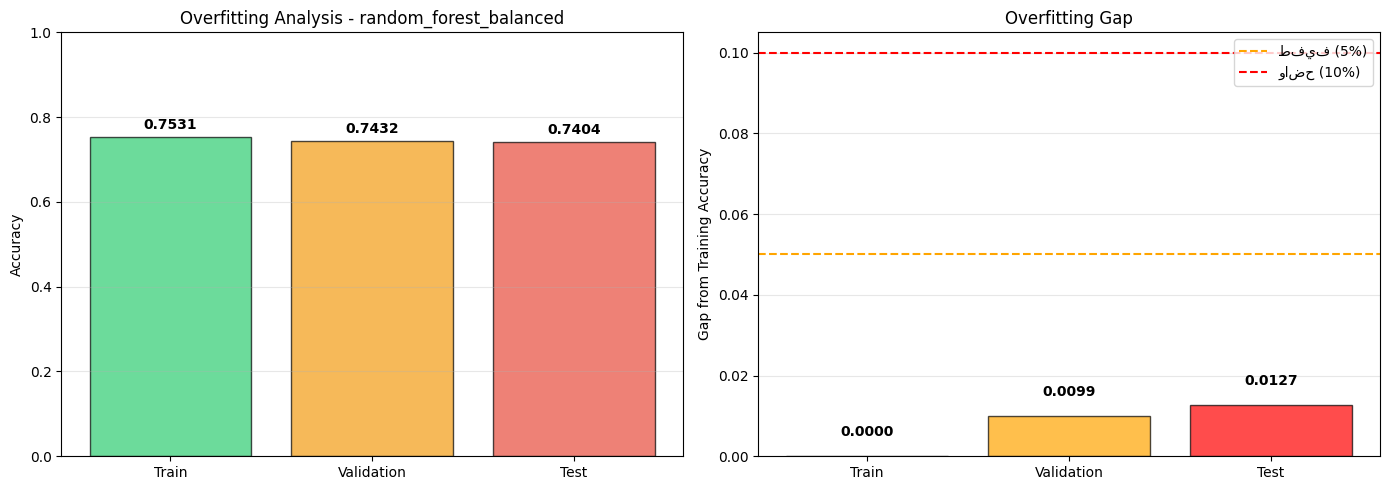

In [17]:
# رسم بياني مقارن لـ Overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# الرسم الأول: مقارنة الـ Accuracy على جميع المجموعات
datasets = ["Train", "Validation", "Test"]
accuracies = [train_acc, val_acc, test_acc]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

ax1.bar(datasets, accuracies, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel("Accuracy")
ax1.set_title(f"Overfitting Analysis - {best_model_name}")
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# إضافة القيم على الأعمدة
for i, (dataset, acc) in enumerate(zip(datasets, accuracies)):
    ax1.text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontweight='bold')

# الرسم الثاني: الفروقات من التدريب
gaps = [0, train_val_gap, train_test_gap]
ax2.bar(datasets, gaps, color=['green', 'orange', 'red'], alpha=0.7, edgecolor='black')
ax2.set_ylabel("Gap from Training Accuracy")
ax2.set_title("Overfitting Gap")
ax2.axhline(y=0.05, color='orange', linestyle='--', label='طفيف (5%)')
ax2.axhline(y=0.10, color='red', linestyle='--', label='واضح (10%)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# إضافة القيم على الأعمدة
for i, (dataset, gap) in enumerate(zip(datasets, gaps)):
    ax2.text(i, gap + 0.005, f'{gap:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
